# Flight Delay Prediction - Conditional Regressor and Two-Stage Evaluation

This notebook does **not** retrain the classifier. The classifier is trained
in `02_model_training_from_cleaned_FINAL.ipynb` and loaded here from
`models/flight_delay_classifier.joblib`.

This notebook trains Model 2 only:

- Conditional regressor target: `dep_delay_min`
- Training rows: only delayed flights, `dep_delay_min > 15`
- Interpretation: if this flight is delayed, approximately how many minutes
  will it be delayed?

It then combines the already-trained classifier with the new regressor for
two-stage evaluation.

In [14]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    median_absolute_error,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    root_mean_squared_error,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
PROJECT_DIR = Path("..").resolve()
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
MEDIA_DIR = PROJECT_DIR / "media" / "training"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MEDIA_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_PATH = DATA_DIR / "flight_features_cleaned_for_modeling.csv"
CLASSIFIER_PATH = MODEL_DIR / "flight_delay_classifier.joblib"
CLASSIFIER_METADATA_PATH = MODEL_DIR / "flight_delay_classifier_metadata.json"
REGRESSOR_PATH = MODEL_DIR / "flight_delay_regressor.joblib"
REGRESSOR_METADATA_PATH = MODEL_DIR / "flight_delay_regressor_metadata.json"
TWO_STAGE_METADATA_PATH = MODEL_DIR / "two_stage_model_metadata.json"

plt.rcParams["figure.dpi"] = 110

print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("MEDIA_DIR:", MEDIA_DIR)

DATA_DIR: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data
MODEL_DIR: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\models
MEDIA_DIR: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\media\training


## 1. Load Cleaned Data and Existing Classifier

If `flight_delay_classifier.joblib` is missing, run notebook `02` first.

In [15]:
if not CLEAN_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found: {CLEAN_PATH}. Run notebooks/01_eda.ipynb first."
    )
if not CLASSIFIER_PATH.exists():
    raise FileNotFoundError(
        f"Classifier model not found: {CLASSIFIER_PATH}. Run notebook 02 first."
    )
if not CLASSIFIER_METADATA_PATH.exists():
    raise FileNotFoundError(
        f"Classifier metadata not found: {CLASSIFIER_METADATA_PATH}. Run notebook 02 first."
    )

df = pd.read_csv(CLEAN_PATH)

try:
    classifier_model = joblib.load(CLASSIFIER_PATH)
except Exception as exc:
    raise RuntimeError(
        "Could not load models/flight_delay_classifier.joblib. "
        "This usually means the classifier was saved with a different scikit-learn "
        "version than the current notebook kernel. Run notebook 02 once in the same "
        "environment/kernel that you will use for notebook 03, then rerun this notebook."
    ) from exc

with open(CLASSIFIER_METADATA_PATH, "r", encoding="utf-8") as f:
    classifier_metadata = json.load(f)

TARGET_CLASS = "is_delayed"
TARGET_REG = "dep_delay_min"
TIME_COL = "dep_scheduled_utc"
REQUIRED_COLUMNS = [TARGET_CLASS, TARGET_REG, TIME_COL]

missing_required = [col for col in REQUIRED_COLUMNS if col not in df.columns]
if missing_required:
    raise ValueError(
        "Cleaned dataset is missing required columns: "
        f"{missing_required}. Update and rerun 01_eda.ipynb so the cleaned CSV "
        "keeps is_delayed, dep_delay_min, and dep_scheduled_utc."
    )

if df[TARGET_CLASS].dtype == "object":
    df[TARGET_CLASS] = df[TARGET_CLASS].map(
        {"t": 1, "f": 0, "True": 1, "False": 0, "1": 1, "0": 0, True: 1, False: 0}
    )

df[TARGET_CLASS] = pd.to_numeric(df[TARGET_CLASS], errors="coerce")
df[TARGET_REG] = pd.to_numeric(df[TARGET_REG], errors="coerce")
df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True, errors="coerce")

invalid_required = df[REQUIRED_COLUMNS].isna().any(axis=1).sum()
if invalid_required:
    raise ValueError(
        f"Found {invalid_required:,} rows with missing/invalid required values. "
        "Fix 01_eda.ipynb before training."
    )

df[TARGET_CLASS] = df[TARGET_CLASS].astype(int)
if set(df[TARGET_CLASS].unique()) != {0, 1}:
    raise ValueError("is_delayed must contain exactly binary values 0 and 1.")

if (df[TARGET_REG] < 0).any():
    raise ValueError("dep_delay_min contains negative values. Handle early departures first.")

classifier_threshold = float(
    classifier_metadata.get("tuned_threshold", classifier_metadata.get("default_threshold", 0.5))
)
classifier_name = classifier_metadata.get("selected_model", "loaded classifier")

print(f"Loaded cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("Loaded classifier:", classifier_name)
print("Classifier threshold:", classifier_threshold)
display(df.head())

Loaded cleaned dataset: 8,743 rows x 57 columns
Loaded classifier: Tuned Random Forest
Classifier threshold: 0.36499999999999994


,dep_scheduled_utc,dep_iata,arr_iata,airline_iata,dep_delay_min,is_delayed,is_weekend,dep_latitude,dep_longitude,dep_elevation_ft,...,dep_dow_sin,dep_dow_cos,route,dep_terminal_missing,dep_iata_grp,arr_iata_grp,airline_iata_grp,route_grp,dep_iso_country_grp,arr_iso_country_grp
0,2026-04-10 00:05:00+00:00,SVO,ALA,SU,36.0,1,0,55.976858,37.411210,622.0,...,-0.433884,-0.900969,SVO_ALA,0,SVO,ALA,SU,SVO_ALA,RU,KZ
1,2026-04-10 00:40:00+00:00,IST,ALA,TK,19.0,1,0,41.274874,28.732136,325.0,...,-0.433884,-0.900969,IST_ALA,1,IST,ALA,TK,IST_ALA,TR,KZ
2,2026-04-10 00:40:00+00:00,IST,ALA,MS,19.0,1,0,41.274874,28.732136,325.0,...,-0.433884,-0.900969,IST_ALA,1,IST,ALA,MS,IST_ALA,TR,KZ
3,2026-04-10 00:40:00+00:00,IST,ALA,KC,19.0,1,0,41.274874,28.732136,325.0,...,-0.433884,-0.900969,IST_ALA,1,IST,ALA,KC,IST_ALA,TR,KZ
4,2026-04-10 00:50:00+00:00,LED,ALA,FV,16.0,1,0,59.800301,30.262501,78.0,...,-0.433884,-0.900969,LED_ALA,0,LED,ALA,FV,LED_ALA,RU,KZ


## 2. Shared Feature Matrix

The same feature construction rules as notebook `02` are applied. Targets,
timestamps, post-event fields and ID-like columns are excluded from `X`.

In [16]:
FORBIDDEN_FEATURE_COLS = [
    TARGET_CLASS,
    "is_delayed_int",
    TARGET_REG,
    "status",
    "updated_at",
    TIME_COL,
    "flight_iata",
    "flight_number",
    "airline_icao",
    "dep_terminal",
]

RAW_TO_GROUPED_PAIRS = {
    "dep_iata": "dep_iata_grp",
    "arr_iata": "arr_iata_grp",
    "airline_iata": "airline_iata_grp",
    "route": "route_grp",
    "dep_iso_country": "dep_iso_country_grp",
    "arr_iso_country": "arr_iso_country_grp",
}

present_forbidden = [col for col in FORBIDDEN_FEATURE_COLS if col in df.columns]
X_all = df.drop(columns=present_forbidden).copy()
y_class_all = df[TARGET_CLASS].copy()
y_delay_all = df[TARGET_REG].copy()

raw_cols_to_drop = [
    raw_col
    for raw_col, grouped_col in RAW_TO_GROUPED_PAIRS.items()
    if raw_col in X_all.columns and grouped_col in X_all.columns
]
X_all = X_all.drop(columns=raw_cols_to_drop)

duplicate_int_cols = [
    col for col in X_all.columns if col.endswith("_int") and col[:-4] in X_all.columns
]
X_all = X_all.drop(columns=duplicate_int_cols)

for col in X_all.columns:
    if X_all[col].dtype == "object":
        values = set(X_all[col].dropna().unique().tolist())
        if values.issubset({"t", "f", "True", "False", "0", "1"}):
            X_all[col] = X_all[col].map(
                {"t": 1, "f": 0, "True": 1, "False": 0, "1": 1, "0": 0}
            )

constant_cols = []
near_constant_cols = []
for col in X_all.columns:
    nunique = X_all[col].nunique(dropna=False)
    if nunique <= 1:
        constant_cols.append(col)
    else:
        top_freq = X_all[col].value_counts(normalize=True, dropna=False).iloc[0]
        if top_freq >= 0.995:
            near_constant_cols.append(col)

X_all = X_all.drop(columns=constant_cols + near_constant_cols)

forbidden_remaining = sorted(set(FORBIDDEN_FEATURE_COLS) & set(X_all.columns))
if forbidden_remaining:
    raise ValueError(f"Forbidden leakage columns still present in X: {forbidden_remaining}")

raw_grouped_remaining = sorted(
    raw_col
    for raw_col, grouped_col in RAW_TO_GROUPED_PAIRS.items()
    if raw_col in X_all.columns and grouped_col in X_all.columns
)
if raw_grouped_remaining:
    raise ValueError(
        "Raw high-cardinality columns still present together with grouped versions: "
        f"{raw_grouped_remaining}"
    )

helper_int_remaining = sorted(col for col in X_all.columns if col.endswith("_int"))
if helper_int_remaining:
    raise ValueError(f"Helper *_int columns still present in X: {helper_int_remaining}")

print("Forbidden columns dropped:", present_forbidden)
print("Raw high-cardinality columns dropped:", raw_cols_to_drop)
print("Duplicate *_int columns dropped:", duplicate_int_cols)
print("Constant columns dropped:", constant_cols)
print("Near-constant columns dropped:", near_constant_cols)
print("Final X shape:", X_all.shape)
display(X_all.head())

Forbidden columns dropped: ['is_delayed', 'dep_delay_min', 'dep_scheduled_utc']
Raw high-cardinality columns dropped: ['dep_iata', 'arr_iata', 'airline_iata', 'route', 'dep_iso_country', 'arr_iso_country']
Duplicate *_int columns dropped: []
Constant columns dropped: []
Near-constant columns dropped: []
Final X shape: (8743, 48)


,is_weekend,dep_latitude,dep_longitude,dep_elevation_ft,dep_iso_region,dep_municipality,arr_airport_type,arr_latitude,arr_longitude,arr_elevation_ft,...,dep_hour_cos,dep_dow_sin,dep_dow_cos,dep_terminal_missing,dep_iata_grp,arr_iata_grp,airline_iata_grp,route_grp,dep_iso_country_grp,arr_iso_country_grp
0,0,55.976858,37.411210,622.0,RU-MOS,Moscow,large_airport,43.354267,77.042828,2234.0,...,1.0,-0.433884,-0.900969,0,SVO,ALA,SU,SVO_ALA,RU,KZ
1,0,41.274874,28.732136,325.0,TR-34,Istanbul,large_airport,43.354267,77.042828,2234.0,...,1.0,-0.433884,-0.900969,1,IST,ALA,TK,IST_ALA,TR,KZ
2,0,41.274874,28.732136,325.0,TR-34,Istanbul,large_airport,43.354267,77.042828,2234.0,...,1.0,-0.433884,-0.900969,1,IST,ALA,MS,IST_ALA,TR,KZ
3,0,41.274874,28.732136,325.0,TR-34,Istanbul,large_airport,43.354267,77.042828,2234.0,...,1.0,-0.433884,-0.900969,1,IST,ALA,KC,IST_ALA,TR,KZ
4,0,59.800301,30.262501,78.0,RU-SPE,St. Petersburg,large_airport,43.354267,77.042828,2234.0,...,1.0,-0.433884,-0.900969,0,LED,ALA,FV,LED_ALA,RU,KZ


In [17]:
order = df.sort_values(TIME_COL).index

X_sorted = X_all.loc[order].reset_index(drop=True)
y_class_sorted = y_class_all.loc[order].reset_index(drop=True)
y_delay_sorted = y_delay_all.loc[order].reset_index(drop=True)
time_sorted = df.loc[order, TIME_COL].reset_index(drop=True)
original_sorted = df.loc[order].reset_index(drop=True)

raw_split_idx = int(len(X_sorted) * 0.8)
split_cutoff = time_sorted.iloc[raw_split_idx]

train_mask = time_sorted < split_cutoff
test_mask = time_sorted >= split_cutoff

if train_mask.sum() == 0 or test_mask.sum() == 0:
    raise ValueError("Chronological split produced an empty train or test set.")
if time_sorted.loc[train_mask].max() >= time_sorted.loc[test_mask].min():
    raise ValueError("Chronological split boundary overlaps between train and test.")

X_train = X_sorted.loc[train_mask].copy()
X_test = X_sorted.loc[test_mask].copy()
y_class_train = y_class_sorted.loc[train_mask].copy()
y_class_test = y_class_sorted.loc[test_mask].copy()
y_delay_train = y_delay_sorted.loc[train_mask].copy()
y_delay_test = y_delay_sorted.loc[test_mask].copy()
time_train = time_sorted.loc[train_mask].copy()
time_test = time_sorted.loc[test_mask].copy()
test_original = original_sorted.loc[test_mask].copy()

print("Raw 80/20 split index:", raw_split_idx)
print("Split cutoff:", split_cutoff)
print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")
print("Train period:", time_train.min(), "->", time_train.max())
print("Test period: ", time_test.min(), "->", time_test.max())

display(
    pd.DataFrame(
        {
            "split": ["train", "test"],
            "rows": [len(X_train), len(X_test)],
            "delay_rate": [y_class_train.mean(), y_class_test.mean()],
            "median_delay_min": [y_delay_train.median(), y_delay_test.median()],
        }
    ).round(4)
)

Raw 80/20 split index: 6994
Split cutoff: 2026-04-27 09:50:00+00:00
Train rows: 6,992
Test rows:  1,751
Train period: 2026-04-10 00:05:00+00:00 -> 2026-04-27 09:40:00+00:00
Test period:  2026-04-27 09:50:00+00:00 -> 2026-05-08 05:50:00+00:00


,split,rows,delay_rate,median_delay_min
0,train,6992,0.4610,14.0
1,test,1751,0.4026,13.0


In [18]:
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)
categorical_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", onehot)]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print("Categorical features:", categorical_features)

Numeric features: 37
Categorical features: 11
Categorical features: ['dep_iso_region', 'dep_municipality', 'arr_airport_type', 'arr_iso_region', 'arr_municipality', 'dep_iata_grp', 'arr_iata_grp', 'airline_iata_grp', 'route_grp', 'dep_iso_country_grp', 'arr_iso_country_grp']


## 3. Loaded Classifier Evaluation

This is evaluation only. No classifier training happens in this notebook.

Saved: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\03_classifier_metrics.csv


,model,source,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,brier,TN,FP,FN,TP
0,Tuned Random Forest,loaded_from_02,0.365,0.686,0.6277,0.5214,0.4528,0.905,0.6036,0.2233,275,771,67,638


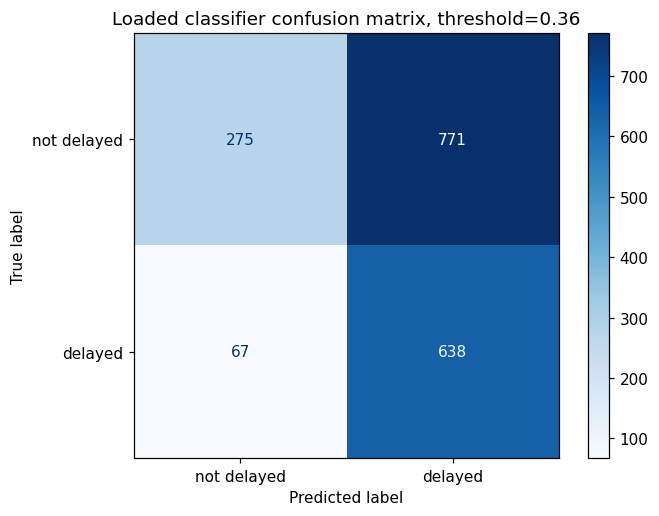

In [19]:
def get_positive_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    score_min = scores.min()
    score_max = scores.max()
    if score_max == score_min:
        return np.full_like(scores, fill_value=0.5, dtype=float)
    return (scores - score_min) / (score_max - score_min)


classifier_test_proba = get_positive_proba(classifier_model, X_test)
classifier_pred_tuned = (classifier_test_proba >= classifier_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_class_test, classifier_pred_tuned).ravel()
classifier_metrics = {
    "model": classifier_name,
    "source": "loaded_from_02",
    "threshold": classifier_threshold,
    "roc_auc": float(roc_auc_score(y_class_test, classifier_test_proba)),
    "pr_auc": float(average_precision_score(y_class_test, classifier_test_proba)),
    "accuracy": float(accuracy_score(y_class_test, classifier_pred_tuned)),
    "precision": float(precision_score(y_class_test, classifier_pred_tuned, zero_division=0)),
    "recall": float(recall_score(y_class_test, classifier_pred_tuned, zero_division=0)),
    "f1": float(f1_score(y_class_test, classifier_pred_tuned, zero_division=0)),
    "brier": float(brier_score_loss(y_class_test, classifier_test_proba)),
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),
}

classifier_metrics_df = pd.DataFrame([classifier_metrics])
classifier_metrics_df.to_csv(DATA_DIR / "03_classifier_metrics.csv", index=False)
print("Saved:", DATA_DIR / "03_classifier_metrics.csv")
display(classifier_metrics_df.round(4))

ConfusionMatrixDisplay.from_predictions(
    y_class_test,
    classifier_pred_tuned,
    display_labels=["not delayed", "delayed"],
    cmap="Blues",
)
plt.title(f"Loaded classifier confusion matrix, threshold={classifier_threshold:.2f}")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "03_loaded_classifier_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 4. Conditional Delay Regressor

The regressor is trained only on train-period delayed flights.

In [20]:
reg_train_mask = y_delay_train > 15
reg_test_mask = y_delay_test > 15

X_reg_train = X_train.loc[reg_train_mask].copy()
y_reg_train = y_delay_train.loc[reg_train_mask].copy()
X_reg_test = X_test.loc[reg_test_mask].copy()
y_reg_test = y_delay_test.loc[reg_test_mask].copy()

if len(X_reg_train) < 100:
    raise ValueError(f"Too few delayed train rows for regression: {len(X_reg_train)}")
if len(X_reg_test) == 0:
    raise ValueError("No actual delayed rows in test for regression evaluation.")

print(f"Regressor train delayed rows: {len(X_reg_train):,}")
print(f"Regressor test actual delayed rows: {len(X_reg_test):,}")


def make_regressor(estimator):
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", estimator)])
    return TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


def evaluate_regressor(model, X, y, model_name, stage):
    pred = np.asarray(model.predict(X), dtype=float)
    pred = np.clip(pred, 0, None)
    residual = pred - y.to_numpy()
    return {
        "model": model_name,
        "stage": stage,
        "mae": float(mean_absolute_error(y, pred)),
        "median_absolute_error": float(median_absolute_error(y, pred)),
        "rmse": float(root_mean_squared_error(y, pred)),
        "r2": float(r2_score(y, pred)),
    }, pred, residual

Regressor train delayed rows: 3,223
Regressor test actual delayed rows: 705


In [21]:
regressor_baselines = {
    "Dummy median": DummyRegressor(strategy="median"),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "HistGradientBoosting Regressor": HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_leaf_nodes=31, random_state=RANDOM_STATE
    ),
}

regressor_results = []
regressor_models = {}

for name, estimator in regressor_baselines.items():
    print("Training regressor baseline:", name)
    model = make_regressor(estimator)
    model.fit(X_reg_train, y_reg_train)
    metrics, _, _ = evaluate_regressor(model, X_reg_test, y_reg_test, name, stage="baseline")
    regressor_results.append(metrics)
    regressor_models[name] = model

regressor_baseline_df = pd.DataFrame(regressor_results)
display(regressor_baseline_df.sort_values("mae").round(4))

Training regressor baseline: Dummy median
Training regressor baseline: Ridge
Training regressor baseline: Random Forest Regressor
Training regressor baseline: HistGradientBoosting Regressor


,model,stage,mae,median_absolute_error,rmse,r2
0,Dummy median,baseline,18.6511,7.0000,54.0249,-0.0654
1,Ridge,baseline,19.0065,7.8344,52.4673,-0.0049
2,Random Forest Regressor,baseline,19.4618,9.0514,51.2471,0.0413
3,HistGradientBoosting Regressor,baseline,19.5407,8.5305,51.7986,0.0206


In [22]:
regressor_tscv = TimeSeriesSplit(n_splits=4)
regressor_search_spaces = {
    "Tuned Random Forest Regressor": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "regressor__model__n_estimators": [200, 300, 500],
            "regressor__model__max_depth": [None, 6, 10, 15, 20],
            "regressor__model__min_samples_leaf": [1, 2, 5, 10],
            "regressor__model__min_samples_split": [2, 5, 10],
            "regressor__model__max_features": ["sqrt", "log2", None],
        },
        "n_iter": 14,
    },
    "Tuned HistGradientBoosting Regressor": {
        "estimator": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "regressor__model__max_iter": [100, 200, 300],
            "regressor__model__learning_rate": [0.03, 0.05, 0.08, 0.10],
            "regressor__model__max_leaf_nodes": [15, 31, 63],
            "regressor__model__min_samples_leaf": [10, 20, 50],
            "regressor__model__l2_regularization": [0.0, 0.01, 0.1, 1.0],
        },
        "n_iter": 14,
    },
}

regressor_tuned_rows = []
regressor_searches = {}

for name, cfg in regressor_search_spaces.items():
    print("Tuning regressor:", name)
    model = make_regressor(cfg["estimator"])
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=cfg["params"],
        n_iter=cfg["n_iter"],
        scoring="neg_mean_absolute_error",
        cv=regressor_tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    search.fit(X_reg_train, y_reg_train)
    best_model = search.best_estimator_
    metrics, _, _ = evaluate_regressor(best_model, X_reg_test, y_reg_test, name, stage="tuned")
    metrics["best_cv_mae"] = float(-search.best_score_)
    regressor_tuned_rows.append(metrics)
    regressor_models[name] = best_model
    regressor_searches[name] = search

regressor_tuned_df = pd.DataFrame(regressor_tuned_rows)
regressor_metrics_df = pd.concat(
    [regressor_baseline_df, regressor_tuned_df], ignore_index=True
).sort_values(["mae", "rmse"], ascending=True)

regressor_metrics_df.to_csv(DATA_DIR / "03_regressor_metrics.csv", index=False)
print("Saved:", DATA_DIR / "03_regressor_metrics.csv")
display(regressor_metrics_df.round(4))

Tuning regressor: Tuned Random Forest Regressor
Fitting 4 folds for each of 14 candidates, totalling 56 fits
Tuning regressor: Tuned HistGradientBoosting Regressor
Fitting 4 folds for each of 14 candidates, totalling 56 fits
Saved: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\03_regressor_metrics.csv


,model,stage,mae,median_absolute_error,rmse,r2,best_cv_mae
4,Tuned Random Forest Regressor,tuned,18.4367,8.1729,52.6700,-0.0126,13.4651
0,Dummy median,baseline,18.6511,7.0000,54.0249,-0.0654,NaN
1,Ridge,baseline,19.0065,7.8344,52.4673,-0.0049,NaN
5,Tuned HistGradientBoosting Regressor,tuned,19.2230,8.6219,52.1380,0.0077,13.6453
2,Random Forest Regressor,baseline,19.4618,9.0514,51.2471,0.0413,NaN
3,HistGradientBoosting Regressor,baseline,19.5407,8.5305,51.7986,0.0206,NaN


In [23]:
regressor_cv_selection_df = (
    regressor_tuned_df.dropna(subset=["best_cv_mae"])
    .sort_values("best_cv_mae", ascending=True)
    .reset_index(drop=True)
)
if regressor_cv_selection_df.empty:
    raise ValueError("No tuned regressor has a CV MAE score.")

selected_regressor_name = regressor_cv_selection_df.iloc[0]["model"]
selected_regressor_template = regressor_models[selected_regressor_name]
print("Selected regressor by train CV MAE:", selected_regressor_name)
display(regressor_cv_selection_df[["model", "best_cv_mae"]].round(4))

final_regressor = clone(selected_regressor_template)
final_regressor.fit(X_reg_train, y_reg_train)
final_reg_metrics, final_reg_pred, final_reg_residual = evaluate_regressor(
    final_regressor, X_reg_test, y_reg_test, selected_regressor_name, stage="final"
)

final_regressor_df = pd.DataFrame([final_reg_metrics])
display(final_regressor_df.round(4))

regressor_metrics_with_final_df = pd.concat(
    [regressor_metrics_df, final_regressor_df], ignore_index=True
)
regressor_metrics_with_final_df.to_csv(DATA_DIR / "03_regressor_metrics.csv", index=False)
print("Updated:", DATA_DIR / "03_regressor_metrics.csv")

joblib.dump(final_regressor, REGRESSOR_PATH)
print("Saved regressor:", REGRESSOR_PATH)

Selected regressor by train CV MAE: Tuned Random Forest Regressor


,model,best_cv_mae
0,Tuned Random Forest Regressor,13.4651
1,Tuned HistGradientBoosting Regressor,13.6453


,model,stage,mae,median_absolute_error,rmse,r2
0,Tuned Random Forest Regressor,final,18.4367,8.1729,52.67,-0.0126


Updated: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\03_regressor_metrics.csv
Saved regressor: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\models\flight_delay_regressor.joblib


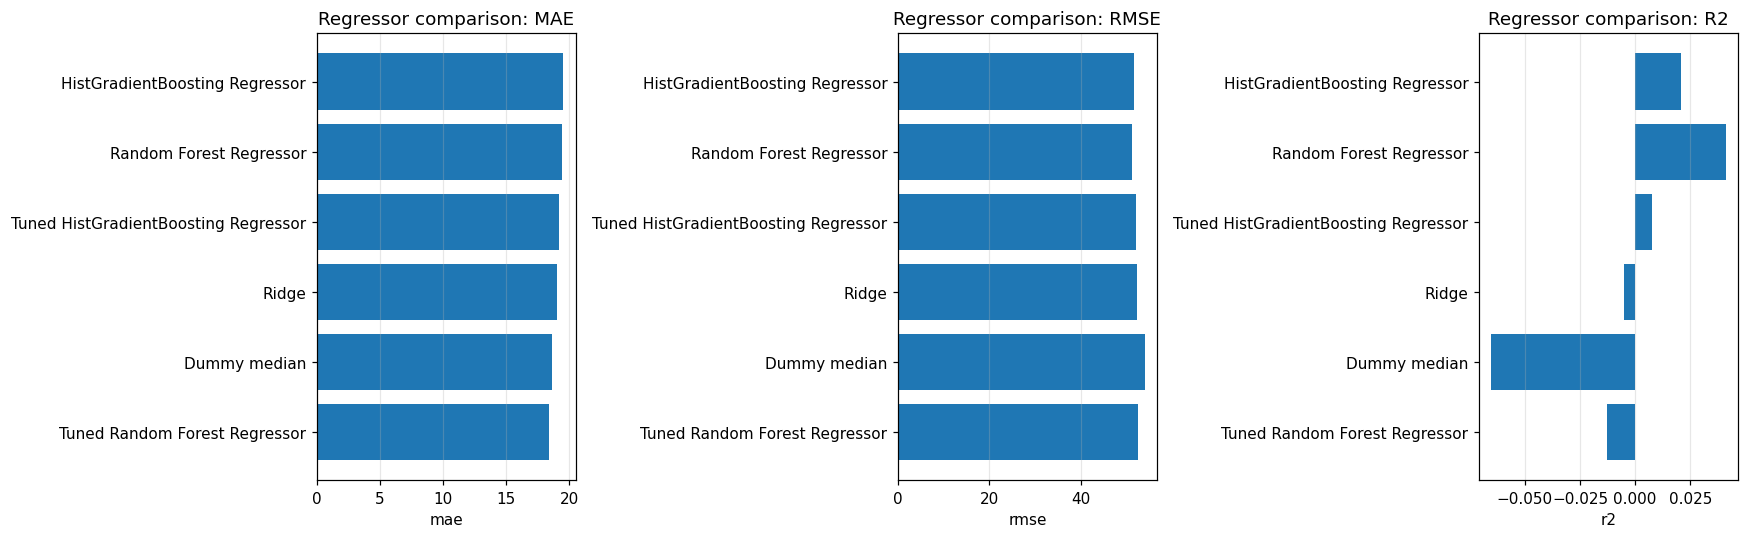

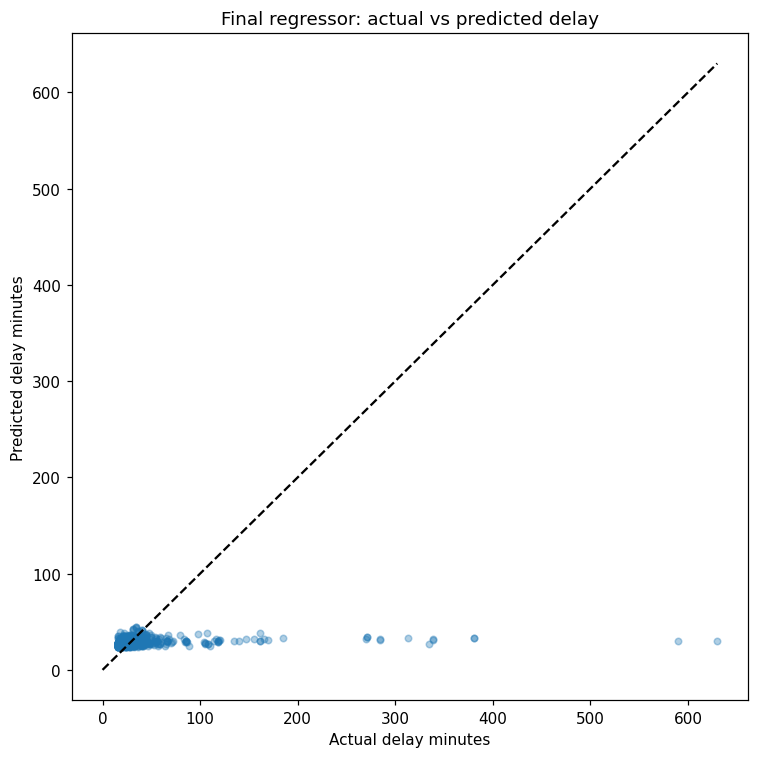

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
reg_plot_df = regressor_metrics_with_final_df.sort_values("mae", ascending=True)
for ax, metric in zip(axes, ["mae", "rmse", "r2"]):
    ax.barh(reg_plot_df["model"], reg_plot_df[metric])
    ax.set_title(f"Regressor comparison: {metric.upper()}")
    ax.set_xlabel(metric)
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(MEDIA_DIR / "03_regressor_metrics_comparison.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_reg_test, final_reg_pred, alpha=0.35, s=18)
limit = max(float(y_reg_test.max()), float(final_reg_pred.max()))
ax.plot([0, limit], [0, limit], linestyle="--", color="black")
ax.set_title("Final regressor: actual vs predicted delay")
ax.set_xlabel("Actual delay minutes")
ax.set_ylabel("Predicted delay minutes")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "03_regressor_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

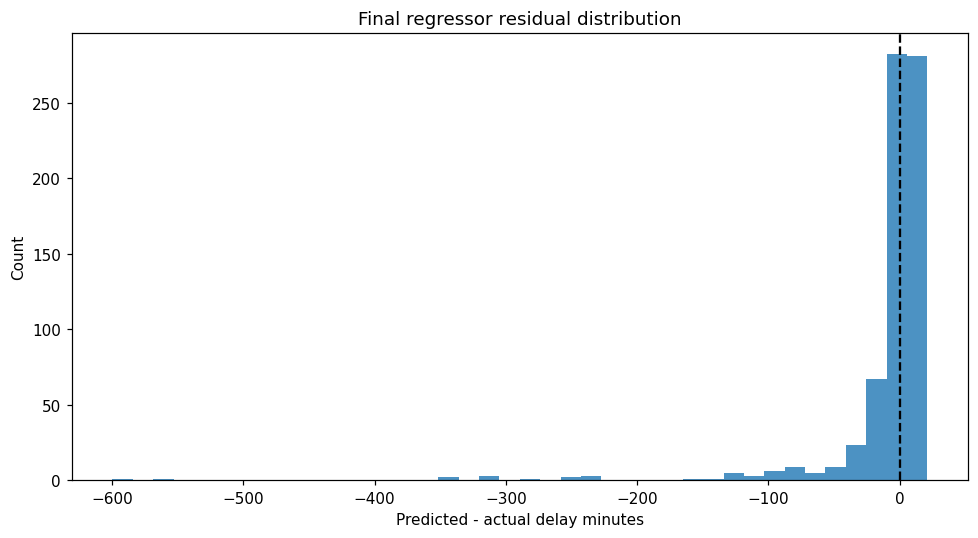

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(final_reg_residual, bins=40, alpha=0.8)
ax.axvline(0, linestyle="--", color="black")
ax.set_title("Final regressor residual distribution")
ax.set_xlabel("Predicted - actual delay minutes")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "03_regressor_residual_distribution.png", bbox_inches="tight")
plt.show()

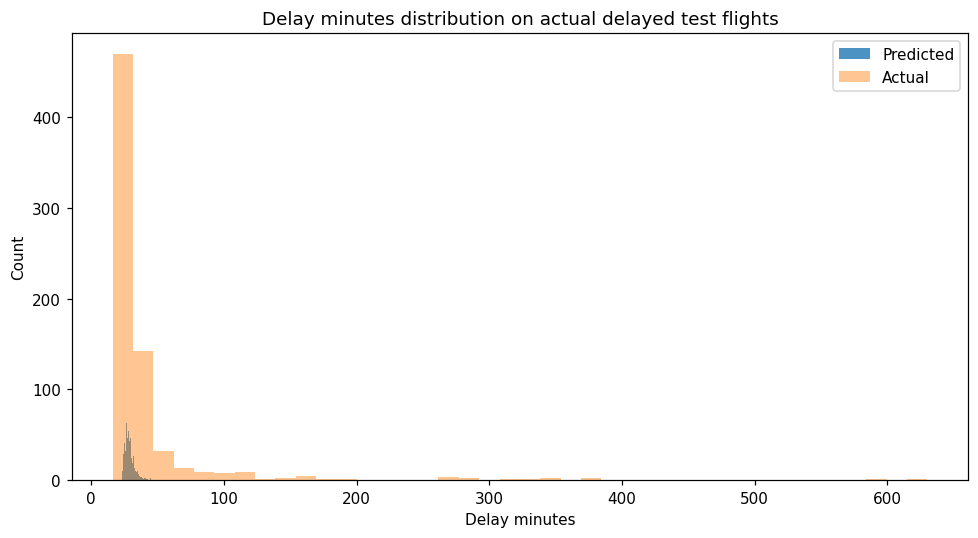

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(final_reg_pred, bins=40, alpha=0.8, label="Predicted")
ax.hist(y_reg_test, bins=40, alpha=0.45, label="Actual")
ax.set_title("Delay minutes distribution on actual delayed test flights")
ax.set_xlabel("Delay minutes")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(MEDIA_DIR / "03_regressor_predicted_delay_distribution.png", bbox_inches="tight")
plt.show()

In [27]:
regression_error_df = test_original.loc[reg_test_mask].copy()
regression_error_df["actual_delay_min"] = y_reg_test.values
regression_error_df["predicted_delay_min"] = final_reg_pred
regression_error_df["residual_min"] = final_reg_residual
regression_error_df["absolute_error_min"] = np.abs(final_reg_residual)
regression_error_df["classifier_delay_probability"] = classifier_test_proba[reg_test_mask.to_numpy()]
regression_error_df["classifier_predicted_is_delayed"] = classifier_pred_tuned[reg_test_mask.to_numpy()]

regression_error_df.to_csv(DATA_DIR / "03_regression_error_analysis.csv", index=False)
print("Saved:", DATA_DIR / "03_regression_error_analysis.csv")
display(
    regression_error_df[
        [
            TIME_COL,
            "actual_delay_min",
            "predicted_delay_min",
            "residual_min",
            "absolute_error_min",
            "classifier_delay_probability",
            "classifier_predicted_is_delayed",
        ]
    ]
    .sort_values("absolute_error_min", ascending=False)
    .head(20)
)

Saved: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\03_regression_error_analysis.csv


,dep_scheduled_utc,actual_delay_min,predicted_delay_min,residual_min,absolute_error_min,classifier_delay_probability,classifier_predicted_is_delayed
7693,2026-04-29 00:40:00+00:00,630.0,30.182452,-599.817548,599.817548,0.628957,1
8454,2026-05-07 09:50:00+00:00,590.0,29.628088,-560.371912,560.371912,0.626064,1
7280,2026-04-28 00:15:00+00:00,381.0,33.199813,-347.800187,347.800187,0.814877,1
7281,2026-04-28 00:15:00+00:00,381.0,33.497982,-347.502018,347.502018,0.814531,1
8158,2026-04-30 06:25:00+00:00,335.0,26.950443,-308.049557,308.049557,0.634157,1
7458,2026-04-28 11:15:00+00:00,339.0,31.226946,-307.773054,307.773054,0.736788,1
7459,2026-04-28 11:15:00+00:00,339.0,31.672926,-307.327074,307.327074,0.735157,1
7874,2026-04-29 12:15:00+00:00,313.0,33.559254,-279.440746,279.440746,0.818353,1
7929,2026-04-29 17:00:00+00:00,284.0,31.300966,-252.699034,252.699034,0.704430,1
7930,2026-04-29 17:00:00+00:00,284.0,31.911903,-252.088097,252.088097,0.706117,1


## 5. Two-Stage Evaluation

Combined output:
`delay_probability`, `predicted_is_delayed`, and
`predicted_delay_minutes_if_delayed`.

Saved: C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\data\03_two_stage_metrics.csv


,value
loaded_classifier,Tuned Random Forest
classifier_threshold,0.365
selected_regressor,Tuned Random Forest Regressor
test_rows,1751
actual_delayed_test_rows,705
actual_delayed_passed_to_regressor,638
actual_delayed_regressor_coverage,0.904965
covered_actual_delayed_mae,19.522709
two_stage_mae_on_all_actual_delayed,20.234735
classifier_pr_auc,0.627683


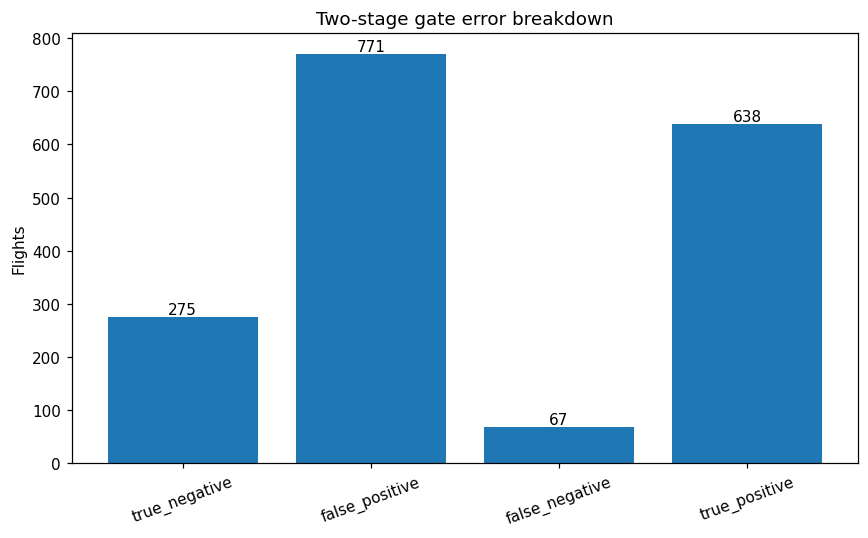

,dep_scheduled_utc,delay_probability,predicted_is_delayed,predicted_delay_minutes_if_delayed,two_stage_predicted_delay_minutes
6992,2026-04-27 09:50:00+00:00,0.378493,1,24.331559,24.331559
6993,2026-04-27 09:50:00+00:00,0.614849,1,26.114094,26.114094
6994,2026-04-27 09:50:00+00:00,0.635984,1,30.668140,30.668140
6995,2026-04-27 09:55:00+00:00,0.597669,1,26.923141,26.923141
6996,2026-04-27 09:55:00+00:00,0.596958,1,26.785647,26.785647


In [28]:
test_delay_probability = classifier_test_proba
test_predicted_is_delayed = classifier_pred_tuned.astype(int)
test_conditional_delay = np.clip(final_regressor.predict(X_test), 0, None)
test_two_stage_delay = np.where(test_predicted_is_delayed == 1, test_conditional_delay, 0.0)

two_stage_output_df = test_original.copy()
two_stage_output_df["delay_probability"] = test_delay_probability
two_stage_output_df["predicted_is_delayed"] = test_predicted_is_delayed
two_stage_output_df["predicted_delay_minutes_if_delayed"] = test_conditional_delay
two_stage_output_df["two_stage_predicted_delay_minutes"] = test_two_stage_delay

actual_delayed_mask = y_class_test.to_numpy() == 1
passed_to_regressor_mask = actual_delayed_mask & (test_predicted_is_delayed == 1)
coverage = float(passed_to_regressor_mask.sum() / actual_delayed_mask.sum())

covered_mae = (
    float(
        mean_absolute_error(
            y_delay_test.to_numpy()[passed_to_regressor_mask],
            test_conditional_delay[passed_to_regressor_mask],
        )
    )
    if passed_to_regressor_mask.sum() > 0
    else np.nan
)

two_stage_mae_actual_delayed_all = float(
    mean_absolute_error(
        y_delay_test.to_numpy()[actual_delayed_mask],
        test_two_stage_delay[actual_delayed_mask],
    )
)

two_stage_metrics = {
    "loaded_classifier": classifier_name,
    "classifier_threshold": float(classifier_threshold),
    "selected_regressor": selected_regressor_name,
    "test_rows": int(len(X_test)),
    "actual_delayed_test_rows": int(actual_delayed_mask.sum()),
    "actual_delayed_passed_to_regressor": int(passed_to_regressor_mask.sum()),
    "actual_delayed_regressor_coverage": coverage,
    "covered_actual_delayed_mae": covered_mae,
    "two_stage_mae_on_all_actual_delayed": two_stage_mae_actual_delayed_all,
    "classifier_pr_auc": classifier_metrics["pr_auc"],
    "classifier_roc_auc": classifier_metrics["roc_auc"],
    "classifier_f1": classifier_metrics["f1"],
    "regressor_mae_actual_delayed": final_reg_metrics["mae"],
    "regressor_rmse_actual_delayed": final_reg_metrics["rmse"],
    "regressor_r2_actual_delayed": final_reg_metrics["r2"],
}

two_stage_metrics_df = pd.DataFrame([two_stage_metrics])
two_stage_metrics_df.to_csv(DATA_DIR / "03_two_stage_metrics.csv", index=False)
print("Saved:", DATA_DIR / "03_two_stage_metrics.csv")
display(two_stage_metrics_df.T.rename(columns={0: "value"}))

tn, fp, fn, tp = confusion_matrix(y_class_test, test_predicted_is_delayed).ravel()
breakdown_df = pd.DataFrame(
    {
        "type": ["true_negative", "false_positive", "false_negative", "true_positive"],
        "count": [tn, fp, fn, tp],
    }
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(breakdown_df["type"], breakdown_df["count"])
ax.set_title("Two-stage gate error breakdown")
ax.set_ylabel("Flights")
ax.tick_params(axis="x", rotation=20)
for i, value in enumerate(breakdown_df["count"]):
    ax.text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "03_two_stage_error_breakdown.png", bbox_inches="tight")
plt.show()

display(
    two_stage_output_df[
        [
            TIME_COL,
            "delay_probability",
            "predicted_is_delayed",
            "predicted_delay_minutes_if_delayed",
            "two_stage_predicted_delay_minutes",
        ]
    ].head()
)

In [29]:
regressor_metadata = {
    "target": TARGET_REG,
    "interpretation": "conditional delay minutes if the flight is delayed",
    "training_filter": "train rows where dep_delay_min > 15",
    "target_transform": "log1p during fit, expm1 during predict via TransformedTargetRegressor",
    "selected_model": selected_regressor_name,
    "selection_metric": "train TimeSeriesSplit MAE, lower is better",
    "train_delayed_rows": int(len(X_reg_train)),
    "test_actual_delayed_rows": int(len(X_reg_test)),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "final_metrics_actual_delayed_test_rows": final_reg_metrics,
}

two_stage_metadata = {
    "approach": "classifier from notebook 02 plus conditional regressor from notebook 03",
    "classifier_model_path": str(CLASSIFIER_PATH),
    "regressor_model_path": str(REGRESSOR_PATH),
    "classifier": classifier_metadata,
    "regressor": regressor_metadata,
    "two_stage_metrics": two_stage_metrics,
    "split": {
        "strategy": "chronological 80/20 split using dep_scheduled_utc only for sorting",
        "split_cutoff": str(split_cutoff),
        "train_start": str(time_train.min()),
        "train_end": str(time_train.max()),
        "test_start": str(time_test.min()),
        "test_end": str(time_test.max()),
    },
    "feature_guards": {
        "dropped_forbidden_columns": present_forbidden,
        "dropped_raw_high_cardinality_columns": raw_cols_to_drop,
        "dropped_duplicate_int_columns": duplicate_int_cols,
        "dropped_constant_columns": constant_cols,
        "dropped_near_constant_columns": near_constant_cols,
    },
}

with open(REGRESSOR_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(regressor_metadata, f, indent=2, ensure_ascii=False)

with open(TWO_STAGE_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(two_stage_metadata, f, indent=2, ensure_ascii=False)

print("Saved metadata:")
print("-", REGRESSOR_METADATA_PATH)
print("-", TWO_STAGE_METADATA_PATH)

Saved metadata:
- C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\models\flight_delay_regressor_metadata.json
- C:\Users\Admin\Desktop\learning\ML_Yerkin\final\ml-final-project\models\two_stage_model_metadata.json


## Report Summary

The classifier is trained once in notebook `02` and acts as the gate: it
estimates whether a flight will be delayed by more than 15 minutes. Notebook
`03` trains only the conditional duration model. If the loaded classifier's
probability crosses its tuned threshold, the flight is passed to the regressor.
The regressor prediction means: if delayed, expect approximately this many
minutes of delay.